# Group commutator $Z = X Y X^\dagger Y^\dagger$

*Sep 23, 2026*

**[Javad Komijani](mailto:jkomijani@gmail.com)**

## Requirements

This notebook was run with the following package versions:

- [lattice_ml](https://github.com/jkomijani/lattice_ml) **v0.2.0**
  (commit [`843f412`](https://github.com/jkomijani/lattice_ml/commit/843f4121e1a0182de480678e6859733f8eaa6d71))
- [normflow](https://github.com/jkomijani/normflow) **v3.0.0**
  (commit [`6f824df`](https://github.com/jkomijani/normflow/commit/6f824df1f2b26134b737c3aafc77779ec1b0ca28))

To install exactly these versions:

    pip install git+https://github.com/jkomijani/normflow@v3.0.0
    pip install git+https://github.com/jkomijani/lattice_ml@v0.2.0

In [ ]:
import lattice_ml, normflow
print(f"lattice_ml {lattice_ml.__version__}, normflow {normflow.__version__}")
if (lattice_ml.__version__, normflow.__version__) != ("0.2.0", "3.0.0"):
    print("Warning: this notebook was run with lattice_ml 0.2.0 and normflow 3.0.0.")

In [1]:
import torch
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

In [2]:
if torch.cuda.is_available():
    torch.set_default_device('cuda')

grab = lambda x: x.detach().cpu().numpy()

torch.manual_seed(42);
# torch.set_num_threads(1)

In [3]:
torch.set_default_dtype(torch.float64)

### Construct a module for updating Z

In [4]:
from normflow.nn import (
    Module_,
    ModuleList_,
    MatrixModule_,
    ChainRuleModule_,
    MultiChannelModule_,
    RQSplineNet_,
)

from normflow.lib.matrix_handles import (
    SU2MatrixParametrizer,
    SU3MatrixParametrizer,
    SUnMatrixEulerParametrizer,
)

from normflow.nn import make_rqs_masked_autoreg_context_module

In [5]:
def assemble_spectral_flow_for_Z(n_c: int, num_spline_segments: int):
    """                                                                         
    Build a network based on RQ splines: useful for transforming Z.
                                                                                
    Returns:                                                                    
        Module: parameter network with:                                         
        - n_c == 2 (SU(2)): one angle (θ) → one RQ spline                       
        - n_c == 3 (SU(3)): two angles (θ, φ) → two-channel RQ spline
    """
    if n_c == 2:
        param_net_ = RQSplineNet_(num_spline_segments)
    elif n_c == 3:
        net0_ = RQSplineNet_(num_spline_segments)
        net1_ = RQSplineNet_(num_spline_segments // 2, symmetric=True)
        param_net_ = MultiChannelModule_([net0_, net1_], channels_axis=-1)
    else:
        raise ValueError(f"n_c = {n_c} is not supported")

    if n_c == 2:
        matrix_handle = SU2MatrixParametrizer()
    else:
        matrix_handle = SU3MatrixParametrizer()

    net_ = MatrixModule_(param_net_, matrix_handle=matrix_handle)
    return net_

### Construct a module for updating Q conditional on Z

In [6]:
from lattice_ml.lie_groups._sun_group_commutator import eig_with_options


class GroupCommutatorQTransform_(Module_):
    """Update Q conditional on Z."""
    
    eig_options = {
        'sort_by': 'zero-sum-angle',
        'randomize_vector_phase': True,
        'project_to_sun': True
    }

    def __init__(self, matrix_transform_):
        super().__init__()
        self.matrix_transform_ = matrix_transform_

    @staticmethod
    def _eigvals_as_context(lam_z):
        return torch.flatten(torch.view_as_real(lam_z), start_dim=-2)
        
    def forward(self, Q, log0=0, *, args):
        """Update Q conditional on Z."""

        Z = args[0]
        lam_z, Omega_z = eig_with_options(Z, **self.eig_options)
        context = self._eigvals_as_context(lam_z)
        
        P = Omega_z.adjoint() @ Q
        P, logj = self.matrix_transform_.forward(P, args=context)
        Q = Omega_z @ P  # Q_new = Q_old @ P_old^dagger @ P_new

        return Q, log0 + logj

    def reverse(self, Q, log0=0, *, args):
        """Reverse update Q conditional on Z."""

        Z = args[0]
        lam_z, Omega_z = eig_with_options(Z, **self.eig_options)
        context = self._eigvals_as_context(lam_z)
        
        P = Omega_z.adjoint() @ Q
        P, logj = self.matrix_transform_.reverse(P, args=context)            
        Q = Omega_z @ P  # Q_new = Q_old @ P_old^dagger @ P_new
        
        return Q, log0 + logj

In [7]:
class PartialTransform_(Module_):
    """Apply a transform to selected features while leaving others unchanged."""

    def __init__(self, transform_: torch.nn.Module, indices: torch.Tensor):
        super().__init__()
        self.transform_ = transform_
        self.register_buffer("indices", indices)

    def forward(self, x, log0=0, args=None):
        """Apply the transform to the selected features."""
        y, logj = self.transform_(x[..., self.indices], args=args)
        x = x.clone()
        x[..., self.indices] = y
        return x, log0 + logj

    def reverse(self, x, log0=0, args=None):
        """Apply the inverse transform to the selected features."""
        y, logj = self.transform_.reverse(x[..., self.indices], args=args)
        x = x.clone()
        x[..., self.indices] = y
        return x, log0 + logj

In [8]:
def assemble_conditional_flow_for_Q(
    n_c: int, num_spline_segments: int, hidden_sizes: tuple
):
    """
    Build a network based on Euler angles.
    """
    if n_c == 2:
        active_indices = torch.tensor([1])
    elif n_c == 3:
        active_indices = torch.tensor([2, 3, 4, 5])
    param_net_ = PartialTransform_(
        make_rqs_masked_autoreg_context_module(
            data_features=len(active_indices),
            context_features=2 * n_c,
            n_segments=num_spline_segments,
            hidden_sizes=hidden_sizes,
            iaf=True
        ),
        active_indices
    )
    matrix_handle = SUnMatrixEulerParametrizer()
    matrix_transform_ = MatrixModule_(param_net_, matrix_handle=matrix_handle)
    return GroupCommutatorQTransform_(matrix_transform_)

In [9]:
from lattice_ml.lie_groups import (
    encode_sun_group_commutator,
    decode_sun_group_commutator,
)


class GroupCommutatorModule_(ChainRuleModule_):
    """
    Trainable SU(N) group-commutator maps: a `ChainRuleModule_` over `(D, Q, Z)`,
    sandwiched between exact maps to `(X, Y)`.

    Note that because of the way encoder is desinged,
    the transformation is identity only in one direction:
         (X, Y) -> (D, Q, Z) -> (X, Y)
    while
        (D, Q, Z) -> (X, Y) -> (D', Q', Z)
    where Q' and D' have some random phases compared to D and Q.
    """

    stacked_XY = False
    
    def forward(self, DQZ, log0=0, start=0):
        """(D, Q, Z) state -> (X, Y) state."""

        DQZ, logj = super().forward(DQZ, start=start)
        (X, Y), logj_decode = decode_sun_group_commutator(*DQZ, return_logj=True)
        
        XY = torch.stack((X, Y), dim=1) if self.stacked_XY else (X, Y)
            
        return XY, log0 + logj + logj_decode

    def reverse(self, XY, log0=0, stop=0):
        """(X, Y) state -> (D, Q, Z) state."""

        
        X, Y = XY.unbind(dim=1) if self.stacked_XY else XY
            
        DQZ, logj_encode = encode_sun_group_commutator(X, Y, return_logj=True)
        DQZ, logj = super().reverse(DQZ, stop=stop)
        
        return DQZ, log0 + logj + logj_encode

In [10]:
def assemble_group_commuator_module(
    n_c: int, num_spline_segments: int, hidden_sizes: tuple
):

    Z_module_ = assemble_spectral_flow_for_Z(n_c, num_spline_segments)
    Q_module_ = assemble_conditional_flow_for_Q(n_c, num_spline_segments, hidden_sizes)
    D_module_ = None  # already uniform, no need to transform
    layers = [D_module_, Q_module_, Z_module_]
    chain_order = [2, 1]

    return GroupCommutatorModule_(layers, chain_order)

In [11]:
from normflow.prior import UniformSUnPrior, UniformDiagonalSUnPrior, PriorList


class UniformGroupCommutatorPrior(PriorList):
    """Flat (Haar) prior over (D, Q) given Z; Z is given, not sampled.

    `log_prob` returning 0 is not a stub: D and Q are drawn from their own
    Haar/flat reference measures, so their log-density w.r.t. that reference is
    genuinely constant. It would change only if the reference did."""

    def __init__(self, n: int, shape=None, **kwargs):
        D_prior = UniformDiagonalSUnPrior(n, shape, **kwargs)
        Q_prior = UniformSUnPrior(n, shape, **kwargs)
        Z_prior = UniformSUnPrior(n, shape, **kwargs)
        super().__init__([D_prior, Q_prior, Z_prior])

    def log_prob(self, x):
        return sum(super().log_prob(x))

In [12]:
class UniformAction:

    def __call__(self, XY):
        X = XY[0] if isinstance(XY, tuple) else XY[:, 0]
        return torch.zeros(len(X), dtype=X.real.dtype, device=X.device)

In [13]:
from normflow import Model


def make_normflow_model(
    n_c: int,
    num_spline_segments: int,
    hidden_sizes: tuple = (32, 32)
):
    network_fn_ = assemble_group_commuator_module(
        n_c, num_spline_segments, hidden_sizes
    )
    prior = UniformGroupCommutatorPrior(n_c, drop_constant_log_prob=True)
    action = UniformAction()
    return Model(prior=prior, network_fn_=network_fn_, action=action)

In [14]:
n_c = 3
num_spline_segments = 4

model = make_normflow_model(n_c, num_spline_segments)


ESS: 0.5223122775838236



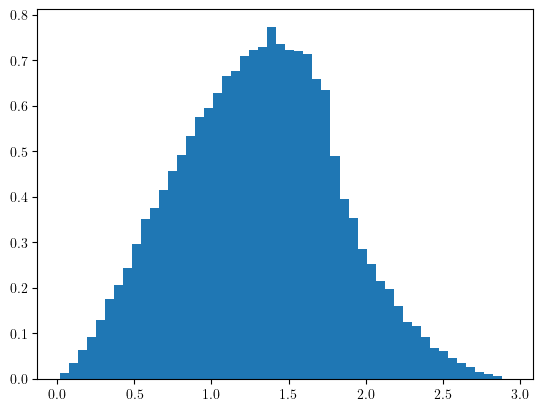

In [15]:
with torch.no_grad():
    _, logq_before_training = model.posterior.sample_(1024 * 64)
    plt.hist(grab(torch.exp(logq_before_training)), bins=50, density=True);


# Compute and print Effective Sample Size (ESS)
ess = model.compute_metrics(batch_size=1024 * 64)[0]              
print(f"\nESS: {ess}\n")

In [16]:
from functools import partial

from torch.optim.lr_scheduler import CosineAnnealingLR

n_epochs = 50_000

training_kwargs = {
    'n_epochs': n_epochs,
    'batch_size': 1024,
    'hyperparam': {'lr': 0.002, 'weight_decay': 0.01},
    'lr_scheduler_class': partial(CosineAnnealingLR, T_max=1 + n_epochs),
    'path_gradient_autodiff': True,
}

In [17]:
load_pretrained_model = True

if load_pretrained_model:
    
    weights_blob = '...'

    model.network_fn_.set_weights_blob(weights_blob)
    
else:

    model.network_fn_.stacked_XY = True
    model.train(**training_kwargs)
    model.network_fn_.stacked_XY = False

Final loss = 0.0115


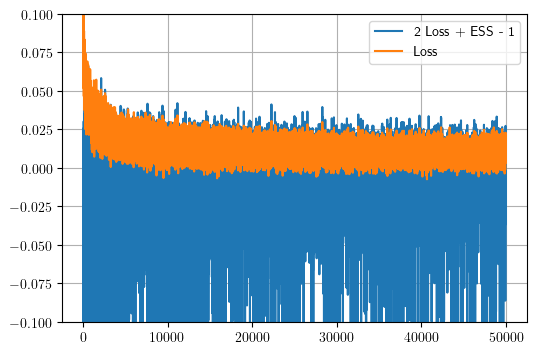

In [18]:
if not load_pretrained_model:
    
    fig, axs = plt.subplots(1, 1, figsize=(6, 4))

    log_dict = model.trainer.logger.load_numpy()
    plt.plot(log_dict['epoch'], 2 * log_dict['loss'] + log_dict['ess'] - 1, '-', label='2 Loss + ESS - 1');
    plt.plot(log_dict['epoch'], log_dict['loss'], '-', label='Loss');
    plt.grid()
    plt.legend()
    plt.ylim([-0.1, 0.1])
    print(f"Final loss = {log_dict['loss'][-1]:.4f}")

In [18]:
# Use a new seed for reproducibility
torch.manual_seed(42 * 2);

In [19]:
@torch.no_grad()
def reverse_flow_sanitychecker(model, n_samples=4, network_fn_=None):
    """Performs a sanity check on the reverse method of modules."""

    if network_fn_ is None:
        network_fn_ = model.network_fn_

    x = model.prior.sample(n_samples)

    network_fn_.stacked_XY = True
    y, logj = network_fn_.forward(x)
    x_hat, minus_logj = network_fn_.reverse(y)    
    y_hat, _ = network_fn_(x_hat)
    network_fn_.stacked_XY = False

    x, x_hat = y, y_hat

    jac_product = torch.exp(logj + minus_logj).cpu().numpy()
    diff = (x - x_hat).abs().reshape(n_samples, -1).sum(dim=1).cpu().numpy()
    norm = x.abs().reshape(n_samples, -1).sum(dim=1).cpu().numpy()

    print(f"The test is performed on {n_samples} samples:")
    print("|x - f⁻¹f(x)| / |x| =", diff / norm)
    print("log ({J_f}⁻¹)       =", -logj.cpu().numpy())
    print("log (J_{f⁻¹})       =", minus_logj.cpu().numpy())
    print("J_f * J_{f⁻¹}   = 1 +", jac_product - 1)


reverse_flow_sanitychecker(model)

The test is performed on 4 samples:
|x - f⁻¹f(x)| / |x| = [6.04236567e-15 1.98551582e-15 3.28008561e-15 2.74827555e-15]
log ({J_f}⁻¹)       = [-0.1707327  -0.03622715  0.02606082  0.11308613]
log (J_{f⁻¹})       = [-0.1707327  -0.03622715  0.02606082  0.11308613]
J_f * J_{f⁻¹}   = 1 + [3.77475828e-15 7.99360578e-15 0.00000000e+00 4.44089210e-16]


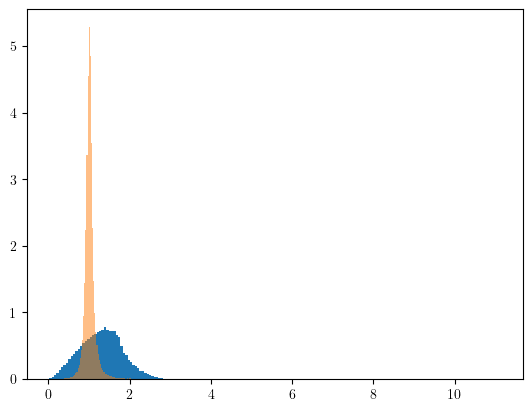

In [20]:
with torch.no_grad():
    _, logq = model.posterior.sample_(1024 * 64)

plt.hist(grab(torch.exp(logq_before_training)), bins=50, density=True);
plt.hist(grab(torch.exp(logq)), bins=400, density=True, alpha=0.5);

In [21]:
# Compute and print Effective Sample Size (ESS)
ess = model.compute_metrics(batch_size=1024 * 64)[0]              
print(f"\nESS: {ess}\n")


ESS: 0.9781507646225795



In [22]:
from lattice_ml.random import (
    rand_sun_group_like,
    rand_diagonal_sun_group_like,
)

In [23]:
def group_commutator(X, Y):
    """Compute and return the group commutator of X and Y."""
    return X @ Y @ X.adjoint() @ Y.adjoint()
    

n_samples = 1024 * 256

n_c = 3
X = UniformSUnPrior(n=n_c).sample(n_samples)
Y = UniformSUnPrior(n=n_c).sample(n_samples)

Z = group_commutator(X, Y)

In [24]:
from lattice_ml.lie_groups import compute_sun_group_commutator_log_prob


@torch.no_grad
def get_samples(model, n_samples):
    """Generate (X', Y') for a target Z' and return the importance weights.

    `logj` is the network's total log-Jacobian for (D, Q, Z) -> (X', Y')
    (spline transform plus the exact `logj_decode`), and `logq = logr - logj`
    is the proposal log-density of the generated sample, so the weight against
    the flat Haar^2 target is exp(-logq).

    - start_from_Z=True: Z' is the Z already in hand, i.e. drawn from the
      commutator density p_Z. `logr = log p_Z(Z')` is NOT an extra weight for
      Z -- it cancels the p_Z that the flow's own Jacobian carries. For a
      perfect conditional sampler logj == log p_Z(Z) pointwise, so w == 1.
      Drop it and w = p_Z(Z): a pure function of Z that would distort samples
      which are already correct.
    - start_from_Z=False: Z' ~ Haar, so logr = 0. This targets Haar^2 with the
      wrong Z-marginal, which caps the ESS at 0.6156 however good the flow is.
    """
    D, Q, _ = model.prior.sample(n_samples)

    Z_prime = Z

    logr_Z_prime = compute_sun_group_commutator_log_prob(Z)
    
    XY_prime, logj = model.network_fn_.forward((D, Q, Z), start=1)
    X_prime, Y_prime = XY_prime
    logq = logr_Z_prime - logj
    return (X_prime, Y_prime, Z_prime), (logr_Z_prime, logj, logq)

In [25]:
from lattice_ml.lie_groups import su3_group_commutator_eigangles_marginal_dist


def eigenangles(M, ordered=False):
    """Eigenvalue angles of a batch of matrices, flattened."""
    angles = torch.linalg.eig(M)[0].angle()
    if ordered:
        angles, _ = torch.sort(angles, dim=-1)
    return angles.ravel()

    
def plot_samples(X_prime, Y_prime, Z_prime):

    fig, axs = plt.subplots(1, 4, figsize=(14, 2.5))
    axs[0].hist2d(eigenangles(Z_prime, ordered=True), eigenangles(X_prime, ordered=True), bins=100);
    axs[1].hist2d(eigenangles(Z_prime, ordered=True), eigenangles(Y_prime, ordered=True), bins=100);
    axs[0].set_xlabel('$Z$')
    axs[0].set_ylabel('$X$')
    axs[1].set_xlabel('$Z$')
    axs[1].set_ylabel('$Y$')

    axs[2].hist2d(eigenangles(X_prime, ordered=True), eigenangles(Y_prime, ordered=True), bins=100);
    axs[2].set_xlabel('$X$')
    axs[2].set_ylabel('$Y$')

    axs[3].hist(eigenangles(X_prime), alpha=0.5, density=True, bins=200, label='X')
    axs[3].hist(eigenangles(Y_prime), alpha=0.5, density=True, bins=200, label='Y')
    axs[3].hist(eigenangles(Z_prime), alpha=0.5, density=True, bins=200, label='Z')
    x_0, pdf_0 = su3_group_commutator_eigangles_marginal_dist(bins=200)
    axs[3].plot(x_0, pdf_0, 'k')
    axs[3].plot(x_0, (3 + 2 * torch.cos(3 * x_0)) / (6 * np.pi), ':k')
    
    axs[3].legend(loc='upper left')
    axs[3].set_ylim([0, 0.4])

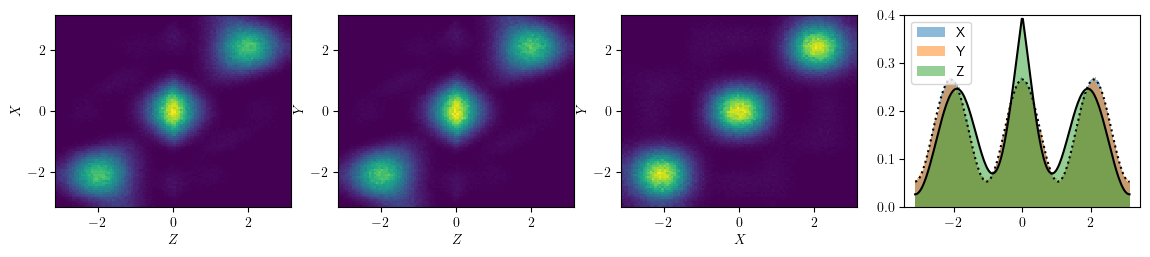

In [26]:
(X_prime, Y_prime, Z_prime), (logr, logj, logq) = get_samples(model, n_samples)

plot_samples(X_prime, Y_prime, Z_prime)

In [27]:
# Compute and print the conditional Effective Sample Size (ESS)
from lattice_ml.stats import compute_ess

ess = compute_ess(logq, UniformAction.__call__(None, (X_prime, Y_prime)))
print(f"\nESS: {ess}\n")


ESS: 0.9782029868953083



# Check how good the $Z$ module is learned

In [28]:
@torch.no_grad
def test_z_module_only(n_samples):
    Z_moulde_ = model.network_fn_.layers[2]
    Z_uniform = UniformSUnPrior(n=3).sample(n_samples)
    Z, logj = Z_moulde_(Z_uniform)
    logq = -logj
    logp = compute_sun_group_commutator_log_prob(Z)
    return Z, logq, logp

0.999856


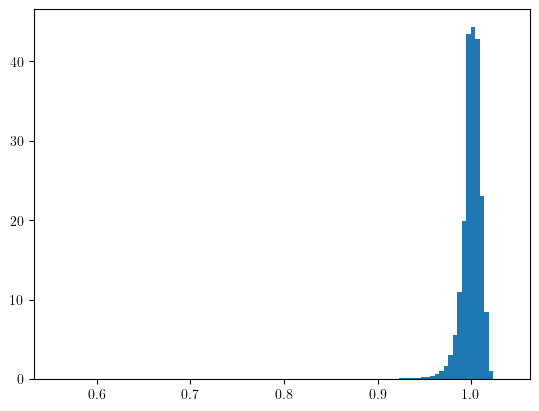

In [29]:
Z, logq, logp = test_z_module_only(1024 * 256)

plt.hist(grab(torch.exp(logq - logp)), bins=100, density=True);


def compute_ess(logq, logp):
    """Rerturn effective sample size (ESS)."""
    logpq = logp - logq
    log_ess = 2*torch.logsumexp(logpq, dim=0) - torch.logsumexp(2*logpq, dim=0)
    ess = torch.exp(log_ess) / len(logpq)  # normalized
    return ess

print(f"{compute_ess(logq, logp):.6g}")

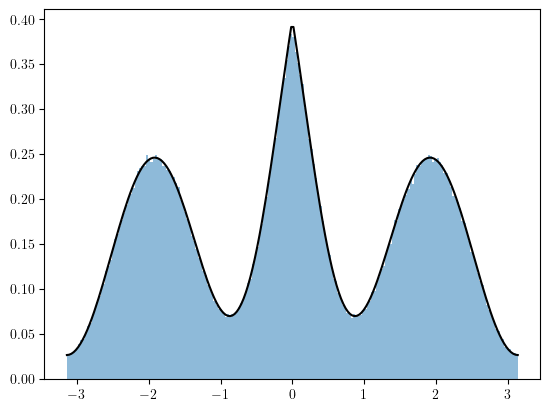

In [30]:
plt.hist(eigenangles(Z), alpha=0.5, density=True, bins=200);

x_0, pdf_0 = su3_group_commutator_eigangles_marginal_dist(bins=200)

plt.plot(x_0, pdf_0, 'k')